# 1. Problématique

**Objectif :** 

- **Question claire :** Quels types de jeux vidéo réussissent le mieux, et peut-on prévoir le succès d’un nouveau jeu à partir de ses caractéristiques ?
- **Contexte** : Un dataset de +64000 jeux vidéos sur 40 ans.

- **Objectif du projet :** Déterminer quels types de jeux vidéos réussissent le mieux pour prévoir le succès d'un jeu donné.
- **Définition de la target supervisée*** : 



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

FILE = "Video_Games.csv" 
df = pd.read_csv(FILE)


# 2. Dataset

**Sources des données :** 

- **Description des variables** 
- **Justification du choix**






# 3. EDA

- **Analyse des distributions** 
- **Visualisations** 
- **Premiers insights**






In [2]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
df.tail()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,11-08-2016,28-01-2019
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,28-02-2019,24-02-2019
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29-09-2023


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [5]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [6]:
df.shape

(64016, 14)

In [7]:
df.isna().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

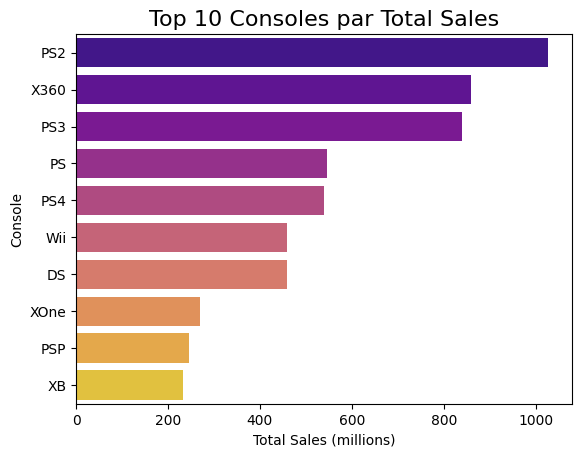

In [9]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=console_sales.values, y=console_sales.index, hue=console_sales.index, palette="plasma")
plt.title("Top 10 Consoles par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Console")
plt.show()

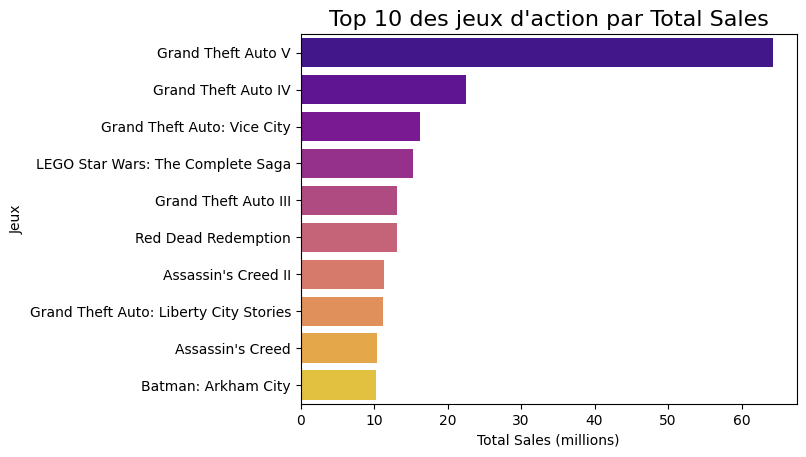

In [10]:
dfActions = df[df['genre'] == 'Action'].groupby('title')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=dfActions.values, y=dfActions.index, hue=dfActions.index, palette="plasma")
plt.title("Top 10 des jeux d'action par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Jeux")
plt.show()

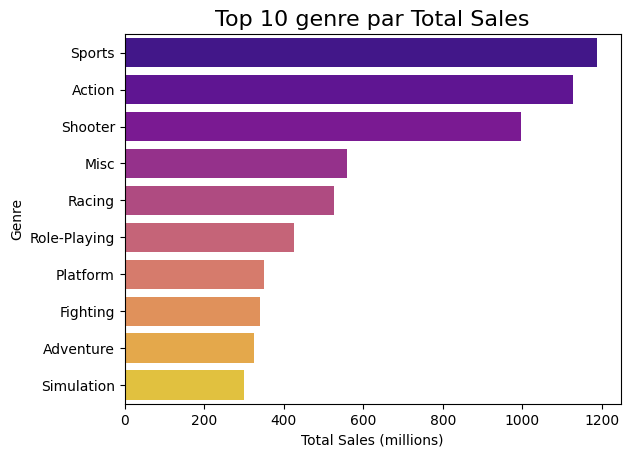

In [11]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=genre_sales.values, y=genre_sales.index, hue=genre_sales.index, palette="plasma")
plt.title("Top 10 genre par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Genre")
plt.show()

# 4.Data Cleaning
- **Gestion des valeurs manquantes**
- **Traitement des outliers**
- **Feature engineering**

In [12]:
df["release_date"] = pd.to_datetime(df["release_date"], format="%d-%m-%Y")
df = df.dropna(subset=['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month


In [13]:
df.dtypes

img                      object
title                    object
console                  object
genre                    object
publisher                object
developer                object
critic_score            float64
total_sales             float64
na_sales                float64
jp_sales                float64
pal_sales               float64
other_sales             float64
release_date     datetime64[ns]
last_update              object
release_year              int32
release_month             int32
dtype: object

In [14]:
df.head(10)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,release_year,release_month
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013,9
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,03-01-2018,2014,11
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002,10
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013,9
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,14-01-2018,2015,11
5,/games/boxart/full_call-of-duty-modern-warfare...,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,NaN,2011,11
6,/games/boxart/full_call-of-duty-black-ops_5Ame...,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,NaN,2010,11
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,02-11-2018,2018,10
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,07-04-2018,2012,11
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,07-04-2018,2012,11


In [15]:
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())
df.isna().sum()

img                  0
title                0
console              0
genre                0
publisher            0
developer           11
critic_score         0
total_sales      38133
na_sales         44345
jp_sales         50277
pal_sales        44189
other_sales      41894
release_date         0
last_update      44385
release_year         0
release_month        0
dtype: int64

In [16]:
df = df.drop(columns=['img','na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'last_update','release_date'])

In [17]:
df = df.dropna(subset=['total_sales'])

In [18]:
df.isna().sum()

title            0
console          0
genre            0
publisher        0
developer        3
critic_score     0
total_sales      0
release_year     0
release_month    0
dtype: int64

In [19]:
df = df.dropna(subset=['developer'])

In [20]:
df.isna().sum()

title            0
console          0
genre            0
publisher        0
developer        0
critic_score     0
total_sales      0
release_year     0
release_month    0
dtype: int64

In [21]:
print(df['critic_score'].min(), df['critic_score'].max())

1.0 10.0


In [22]:
df['log_total_sales'] = np.log1p(df['total_sales'])

In [23]:
df = df.drop(columns=['total_sales'])

In [24]:
seuil = 20
editeurs_frequents = df['publisher'].value_counts()[df['publisher'].value_counts() >= seuil].index

df['publisher'] = df['publisher'].apply(lambda x: x if x in editeurs_frequents else 'Other')

# 5.Machine Learning Non Supervisé
- **Préparation des features**
- **Scaling**
- **KMeans**
- **Choix du nombre de clusters avec Elbow et Silhouette**
-  **Interprétation des clusters**

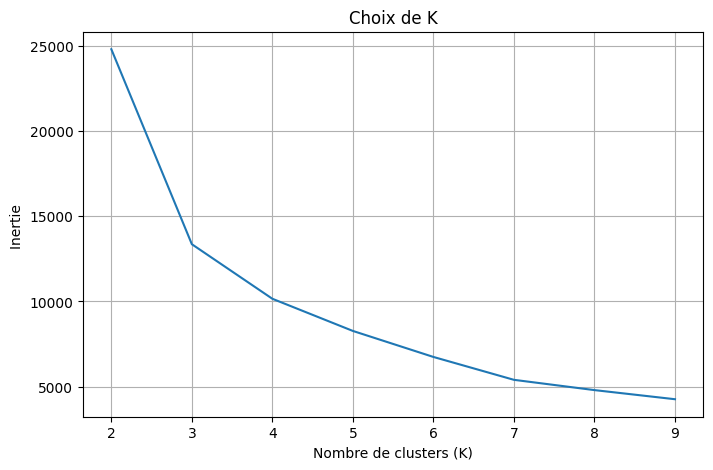

In [25]:
features = ['critic_score', 'log_total_sales']
scaler = StandardScaler()

X = scaler.fit_transform(df[features])
inertia = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertia)
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie ')
plt.title('Choix de K')
plt.grid(True)
plt.show()

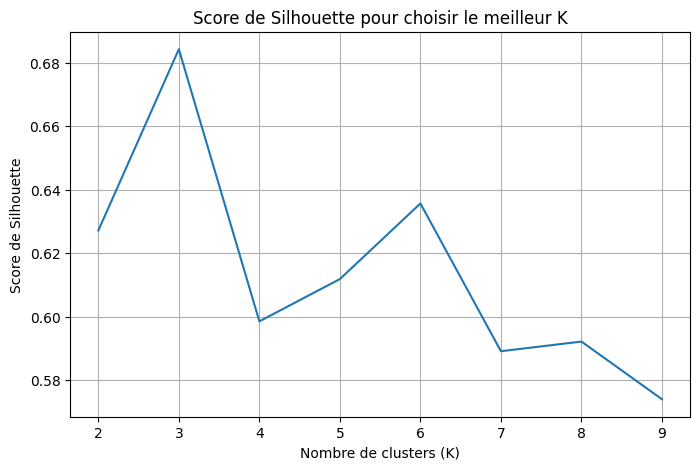

In [26]:
silhouette_scores = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X) 
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores)
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Score de Silhouette')
plt.title('Score de Silhouette pour choisir le meilleur K')
plt.grid(True)
plt.show()

In [27]:
best_k = 3

modele_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
modele_kmeans.fit(X)
df['cluster'] = modele_kmeans.labels_
moyennes_clusters = df.groupby('cluster')[features].mean()
print(moyennes_clusters)
print(df['cluster'].value_counts())

         critic_score  log_total_sales
cluster                               
0            7.506219         0.131493
1            7.805919         0.909605
2            5.104926         0.228403
cluster
0    15550
1     2264
2     1015
Name: count, dtype: int64


# 6.Machine Learning Supervisé
- **Définition de la target**
- **Entrainement d'un modèle**
- **Evaluation des performances**
- **Interprétation**
  

In [29]:
from sklearn.model_selection import train_test_split

In [37]:
df_ml = df.drop(columns= ['title','cluster'])
df_encoded = pd.get_dummies(df_ml, drop_first=True)
X = df_encoded.drop(columns=['log_total_sales'])
y = df_encoded['log_total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
modele_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modele_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
predictions_log = modele_rf.predict(X_test)

y_test_reel = np.expm1(y_test)
predictions_reel = np.expm1(predictions_log)

mae = mean_absolute_error(y_test_reel, predictions_reel)
rmse = np.sqrt(mean_squared_error(y_test_reel, predictions_reel))
r2 = r2_score(y_test, predictions_log) 

print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f} millions de copies")
print(f"Erreur Quadratique Moyenne (RMSE) : {rmse:.2f} millions de copies")
print(f"Coefficient de détermination (R2) : {r2:.2f}")

Erreur Absolue Moyenne (MAE) : 0.23 millions de copies
Erreur Quadratique Moyenne (RMSE) : 0.66 millions de copies
Coefficient de détermination (R2) : 0.48


Top 10 des variables les plus importantes :
                          Feature  Importance
0                    critic_score    0.198198
1                    release_year    0.105406
2                   release_month    0.062069
19                     console_PC    0.036457
25                    console_PS4    0.018200
104     publisher_Electronic Arts    0.017803
23                    console_PS2    0.017508
101           publisher_EA Sports    0.015565
2737           developer_Treyarch    0.015230
2734  developer_Traveller's Tales    0.013660


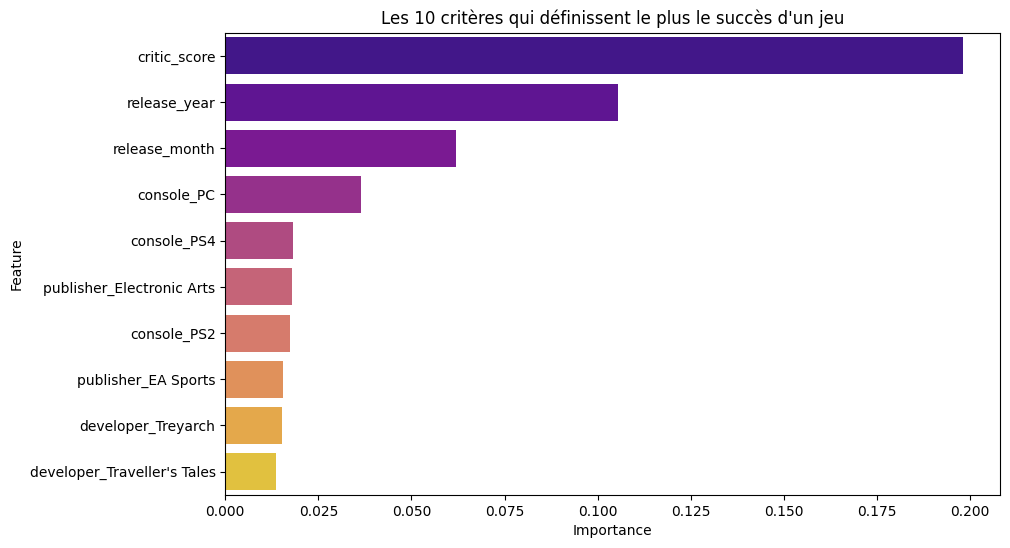

In [43]:
importances = modele_rf.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print("Top 10 des variables les plus importantes :")
print(feature_importance_df.head(10))


plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['Importance'].head(10), y=feature_importance_df['Feature'].head(10), hue=feature_importance_df['Feature'].head(10), palette="plasma")
plt.title("Les 10 critères qui définissent le plus le succès d'un jeu")
plt.xlabel("Importance")
plt.show()

# 7.Conclusion
- **Résultats principaux**
- **Limites du projet**
- **Pistes d'amélioration**